# Plotting vector data

Vector data such as wind fields consist of two components: *U* (zonal, east-west) and *V* (meridional, north-south). earthkit-plots provides three methods for visualising vector fields on a map:

| Method | Description | Best for |
|--------|-------------|----------|
| `quiver` | Arrows scaled by magnitude | Seeing both direction and speed |
| `barbs` | Meteorological wind flags | Operational / aviation contexts |
| `streamplot` | Continuous flow lines | Showing large-scale flow patterns |

This notebook covers all three methods, then explores **resampling** to control arrow density, and finally **styles** to colour vectors by wind speed.

### The data: Storm Ophelia (October 2017)

Throughout this notebook we use 850 hPa wind data from Storm Ophelia, which struck the UK and Ireland in October 2017. The sample file contains two fields: *U* (zonal) and *V* (meridional) wind components.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "storm_ophelia_wind_850.grib").to_fieldlist()
data.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,u,2017-10-16,2017-10-16,0 days,850,pressure,0,regular_ll
1,v,2017-10-16,2017-10-16,0 days,850,pressure,0,regular_ll


earthkit-plots **automatically detects** the U and V components from standard metadata, so you can pass the whole FieldList (or xarray dataset) directly to any vector plotting method. You can also supply the components explicitly with `u=` and `v=` if your data uses non-standard naming.

### Quiver

The `quiver` method draws arrows whose direction shows the wind direction and whose length is proportional to wind speed. See the [matplotlib quiver documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) for a full list of available kwargs and styles.

Pass the whole FieldList and earthkit-plots handles the rest:

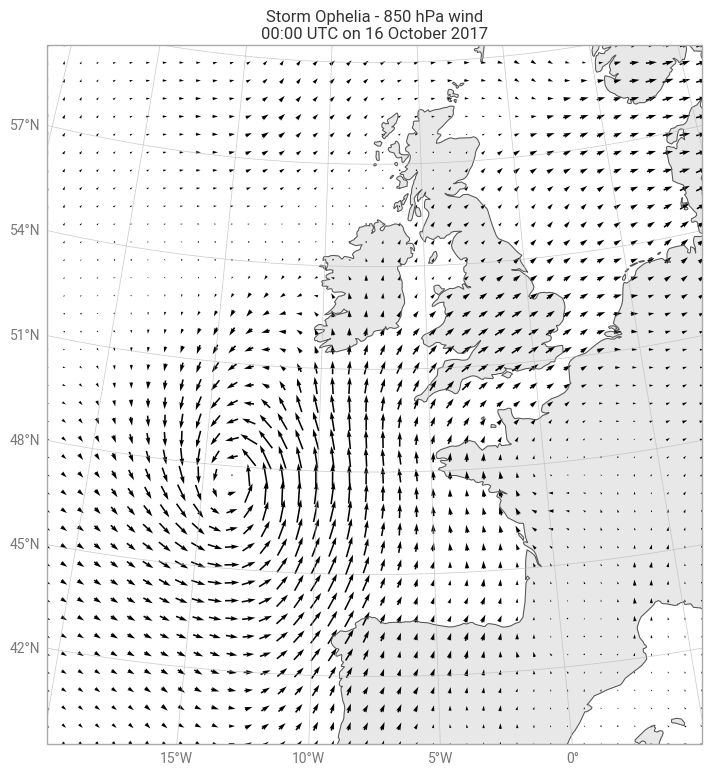

In [2]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.quiver(data)
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa wind\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()

You can also provide U and V explicitly - useful when components are stored separately or carry non-standard metadata:

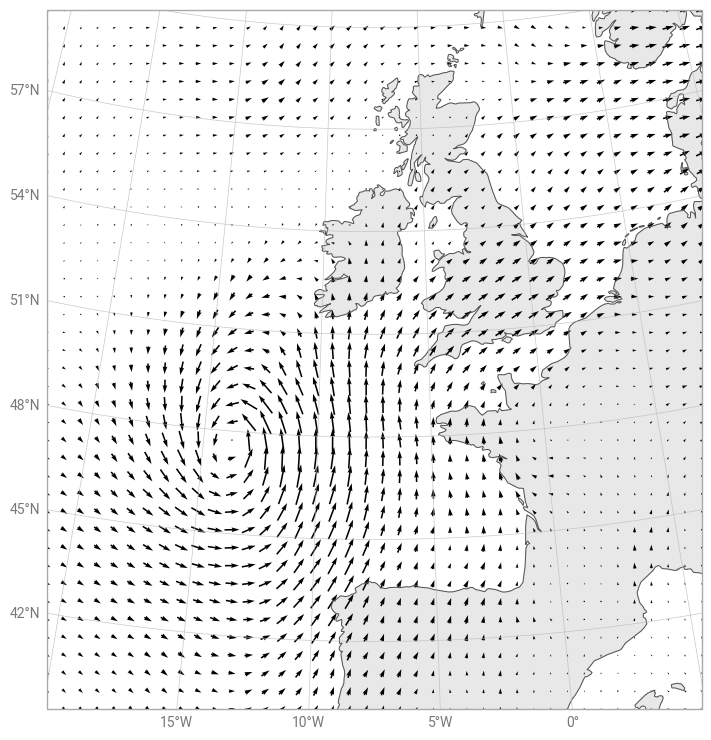

In [3]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.quiver(u=data[0], v=data[1])
chart.land()
chart.coastlines()
chart.gridlines()
chart.show()

### Barbs

Wind barbs are a very common way to represent wind in operational meteorology. Each barb encodes speed using a combination of flags, full barbs, and half-barbs.  See the [matplotlib barbs documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barbs.html) for a full list of available kwargs and styles.

The API is identical to `quiver`:

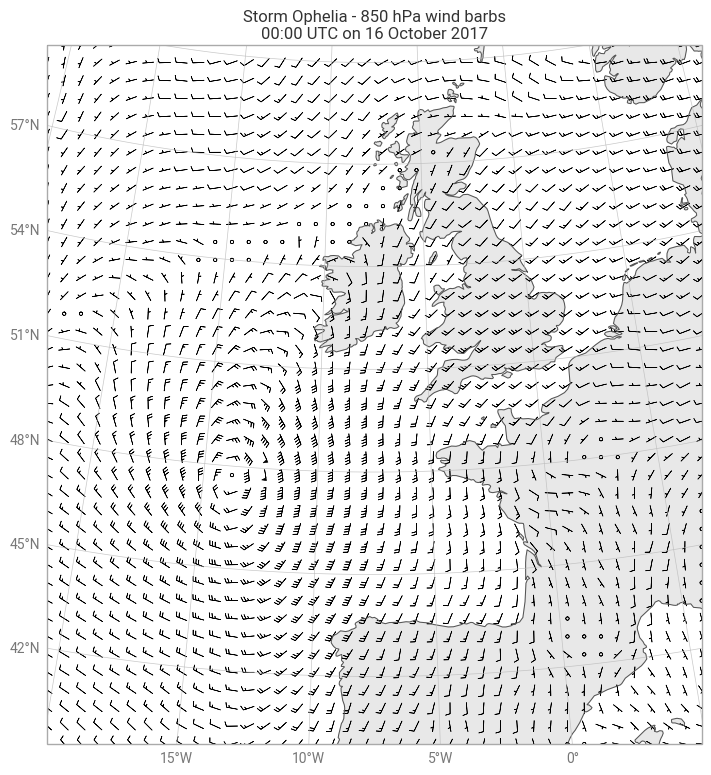

In [4]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.barbs(data)
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa wind barbs\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()

### Streamplot

Streamlines trace the continuous flow of the vector field. They are good for communicating large-scale circulation patterns but do not convey speed directly. See the [matplotlib streamplot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.streamplot.html) for a full list of available kwargs and styles.

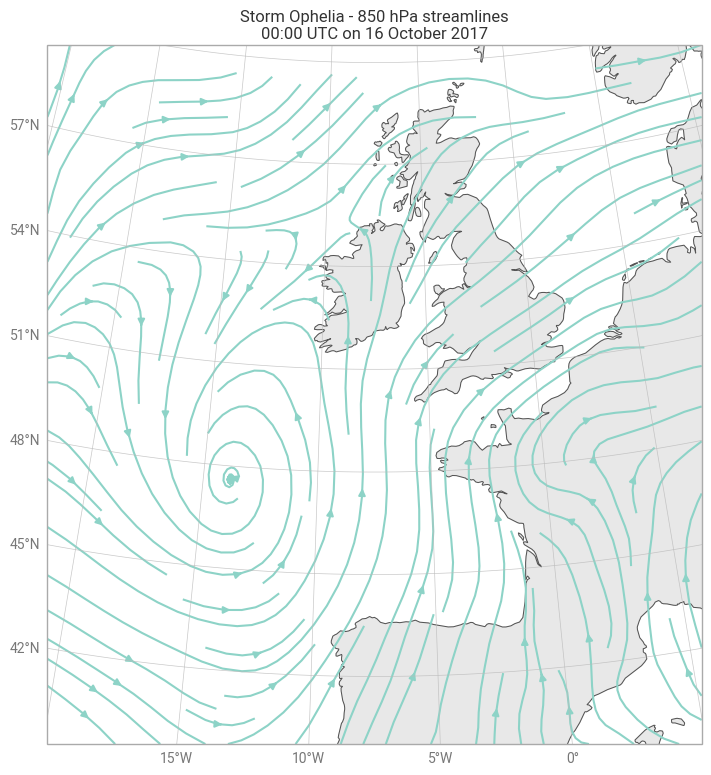

In [5]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.streamplot(data)
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa streamlines\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()

### Resampling

At the default resolution, vector plots can become cluttered - arrows overlap and the overall pattern is hard to read. The `resample=` argument controls how many vectors are drawn and where, with some sensible defaults that made the above plots easy to read. We can see how these plots would look if we plotted every point as an arrow by switching resampling off:

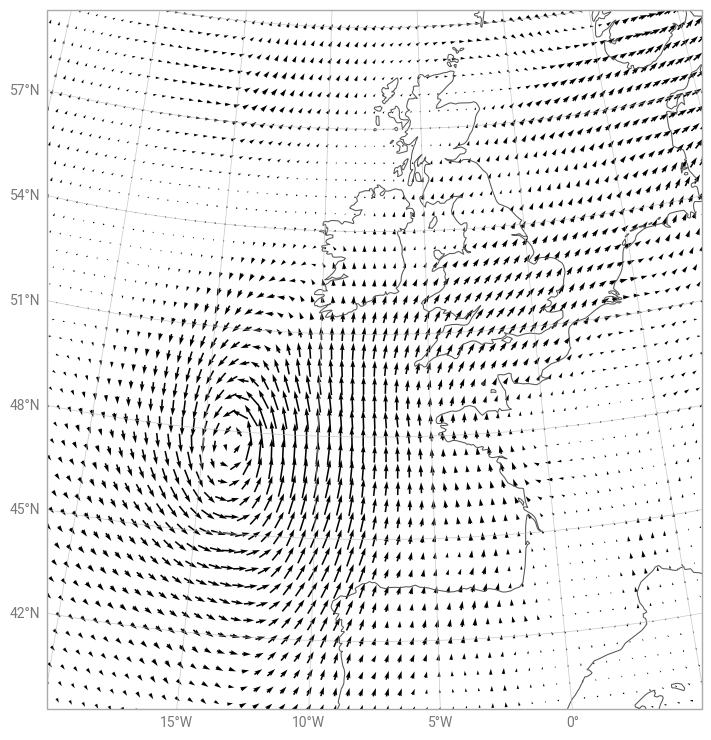

In [6]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.quiver(data, resample=None)
chart.coastlines()
chart.gridlines()
chart.show()

It's not too bad in this case as we have a small domain and our data resolution is not super high - but you can see how this could get hard to read as resolution increases. Because we are plottign in a different projection to the original data, there are also some areas of low and high arrow density.

To mitigate this, earthkit-plots provides two resampling strategies:

| Class | What it does |
|-------|--------------|
| `Subsample` | Thins the *existing* grid points - fast, stays on the original grid structure |
| `Bilinear` | Interpolates onto a *new* regular grid aligned with the map projection - uniform density regardless of projection |

Both are imported from `earthkit.plots.resample`.

#### Subsampling

`Subsample` selects a subset of the original grid points. The `mode` argument controls how:

- **`stride`** - keep every *n*th point in x and y.
- **`fixed`** - keep approximately *n* evenly spaced points in x and y.

Plotting the original grid cells alongside the arrows makes it easy to see how the spacing relates to the underlying data:

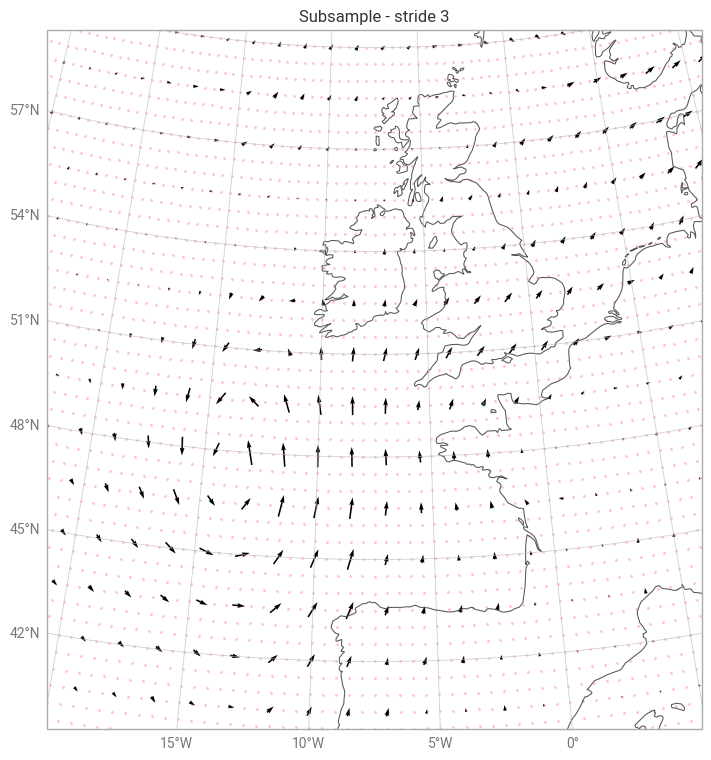

In [7]:
from earthkit.plots.resample import Subsample

chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.grid_points(data[0], alpha=0.2)  # original grid points for reference
chart.quiver(data, resample=Subsample(3, mode="stride"))
chart.coastlines()
chart.gridlines()
chart.title("Subsample - stride 3")
chart.show()

With `mode="fixed"` you specify the *target count* rather than the step. You can also set different densities in x and y with `nx=` and `ny=` - but note that based on your data resolution, you may in reality get a slightly different number of points to what you ask for, as spacing is deliberately kept consistent:

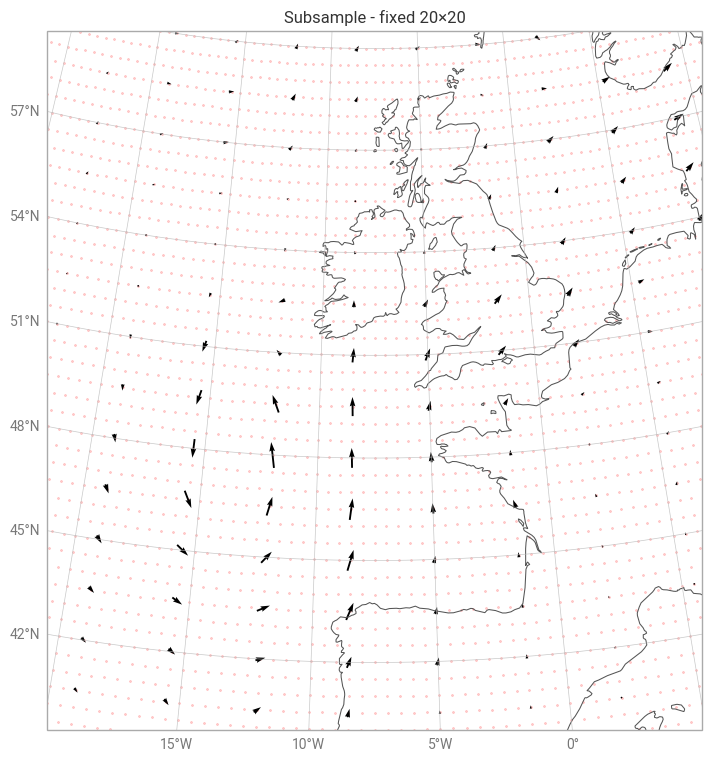

In [8]:
chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.grid_points(data[0], alpha=0.2)
chart.quiver(data, resample=Subsample(nx=20, ny=20, mode="fixed"))
chart.coastlines()
chart.gridlines()
chart.title("Subsample - fixed 20×20")
chart.show()

#### Bilinear interpolation

`Bilinear` interpolates the vector field onto a new regular grid that is aligned with the **map projection** rather than the original data's grid. This gives a visually uniform density of arrows regardless of which projection you use - and unlike `Subsample`, you always get exactly the number of points you request. This method is the **default way** to visualise wind in earthkit-plots.

The original grid points are shown again so you can see that the resampled arrows are no longer aligned with the source data:

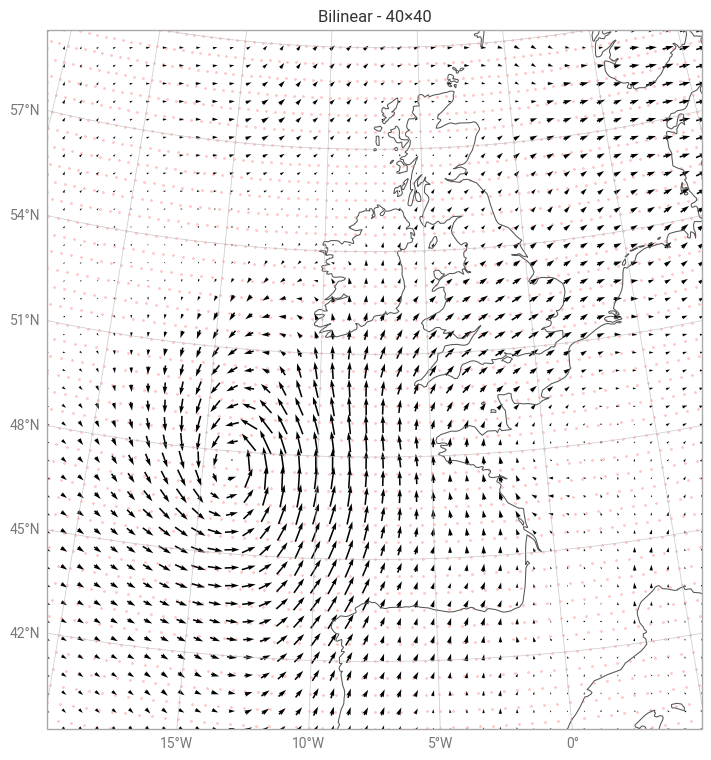

In [9]:
from earthkit.plots.resample import Bilinear

chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.grid_points(data[0], alpha=0.2)
chart.quiver(data, resample=Bilinear(40))
chart.coastlines()
chart.gridlines()
chart.title("Bilinear - 40×40")
chart.show()

### Styles

By default, all arrows are drawn in a single colour. Passing a `Style` colours each arrow by its **wind speed** (the magnitude of U and V), using the same `Style` class introduced in the styles notebook.

The `units=` key inside the style controls the unit used for both the colour mapping and the legend label. Here we colour quiver arrows by speed in m s⁻¹:

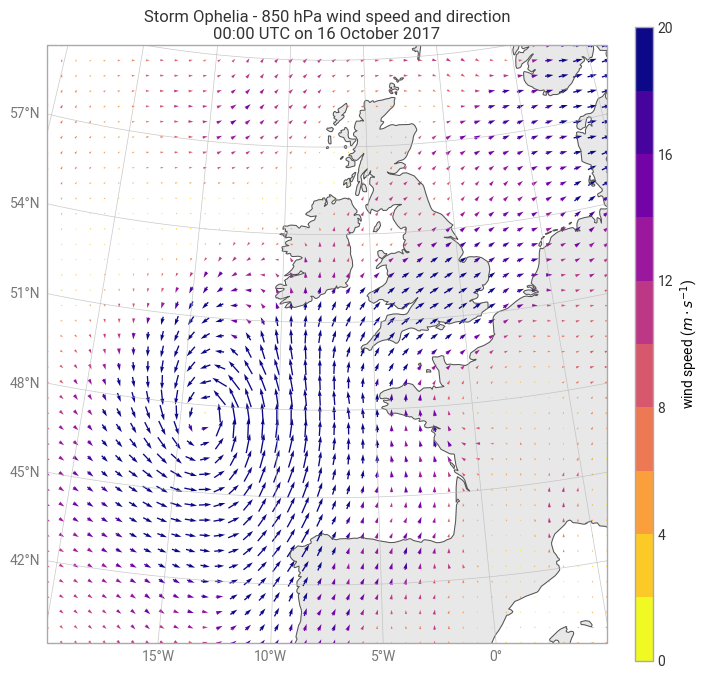

In [10]:
speed_style = ekp.styles.Style(
    colors="plasma_r",
    levels=range(0, 22, 2),
    units="m s-1",
)

chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.quiver(data, style=speed_style)
chart.legend(label="wind speed ({units})", location="right")
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa wind speed and direction\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()

The same style works identically with `barbs`:

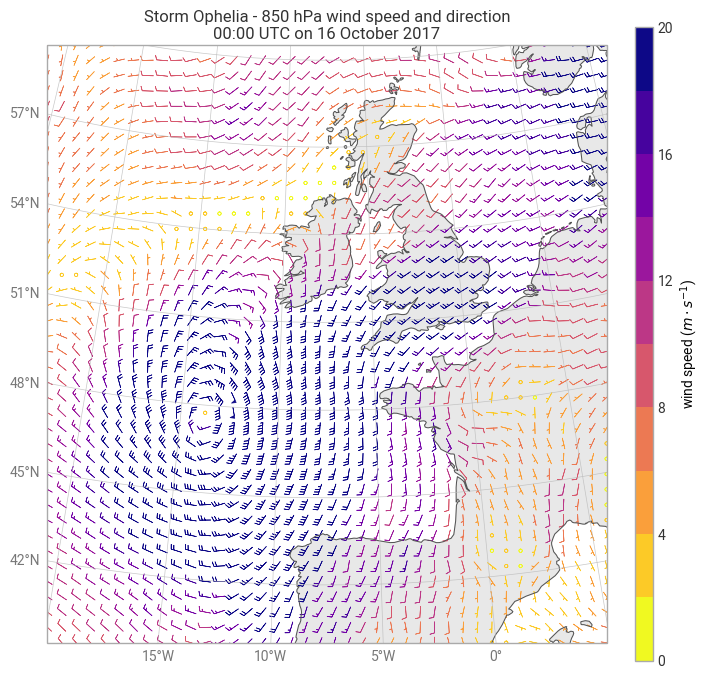

In [11]:
speed_style = ekp.styles.Style(
    colors="plasma_r",
    levels=range(0, 22, 2),
    units="m s-1",
)

chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.barbs(data, style=speed_style)
chart.legend(label="wind speed ({units})", location="right")
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa wind speed and direction\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()

### Exercises

1. Plot the Storm Ophelia wind data as either a quiver or barbs plot, using a style with units of knots.

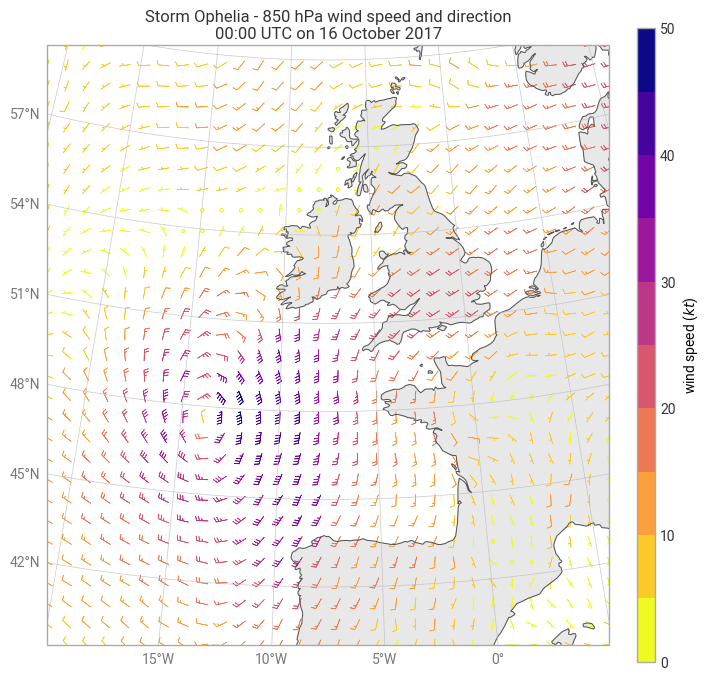

In [12]:
speed_style = ekp.styles.Style(
    colors="plasma_r",
    levels=range(0, 51, 5),
    units="knots",
)

chart = ekp.Map(domain=[-20, 5, 40, 60])
chart.barbs(data, style=speed_style, resample=Bilinear(30))
chart.legend(label="wind speed ({units})", location="right")
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Storm Ophelia - {vertical.level} hPa wind speed and direction\n{time:%H:%M UTC on %-d %B %Y}")
chart.show()